In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

# Get data from arrayExpress: SG treatment subcut

UMAP not yet available on arrayExpress. Implement once this has been updated...

In [3]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16433"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,

)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16433 in: ../data_arrayExpress/E-MTAB-16433
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16433
      Inferred 1 dataset representation: SG (full prefix: treatment_HD4246_SG)
      Selected dataset for in-memory loading: SG (full prefix: treatment_HD4246_SG)
[3/3] Preparing selected dataset.
      Loading selected dataset from disk: E-MTAB-16433/E-MTAB-16433_SG.h5ad


AnnData object with n_obs × n_vars = 7330 × 25470
    obs: 'sample_id', 'library_id', 'treatment', 'mouse_ID', 'batch', 'leiden'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    layers: 'counts', 'log1p'

In [13]:
# Temporary solution: read UMAP from disk
umap_file = '../data/treatment_HD4246_SG_umap.txt'
umap = pd.read_table(umap_file, index_col=0)
print(umap.shape)

(2, 7330)


In [14]:
# Assign umap to adata.obsm
umap = umap.T
# Sanity check order of entries
if umap is not None:
    missing_umap = adata.obs_names.difference(umap.index.astype(str))
    if len(missing_umap) > 0:
        raise ValueError(
            f"UMAP file is missing {len(missing_umap)} observation IDs. "
            f"First few: {list(missing_umap[:5])}"
        )

    umap = umap.copy()
    umap.index = umap.index.astype(str)
    umap = umap.loc[adata.obs_names]
    # Assign to adata
    adata.obsm["X_umap"] = umap.to_numpy()

# Inspect output
adata.obsm['X_umap'][:3, ]

array([[6.4983726, 3.0187151],
       [8.7560005, 9.742954 ],
       [6.3581786, 3.4428399]])

## Read data from disk: SG treatment subcut

In [ ]:
# # Read input data
# dir_data = '../data/'
# file = os.path.join(dir_data, "treatment_HD4246_SG.h5ad")
# adata = sc.read_h5ad(file)

## Annotation

In [ ]:
# # Add annotation
# from utils_treatment_HD4246_SG import anno_leiden_dict

# if adata.uns['leiden']['params']['resolution'] == anno_leiden_dict['resolution']:
#     adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
# else:
#     raise ValueError("Resolution mismatch between adata.uns['leiden'] and anno_leiden_dict.")

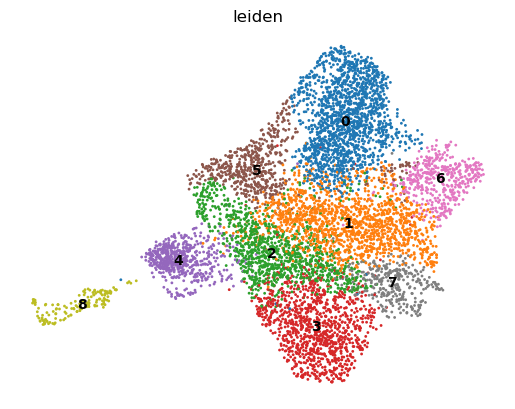

In [15]:
# Ensure order of leiden clustering (str) is available
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
sc.pl.umap(adata, color='leiden', legend_loc='on data', show=True, frameon=False)

In [19]:
# Add annotation to dataset
from utils_treatment_HD4246_SG import anno_leiden_dict

adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
# Order annotation levels by leiden cluster number
adata.obs['anno'] = pd.Categorical(
    adata.obs['anno'],
    categories=[anno_leiden_dict['labels'][f'{i}'] for i in range(len(anno_leiden_dict['labels']))],
    ordered=True
)

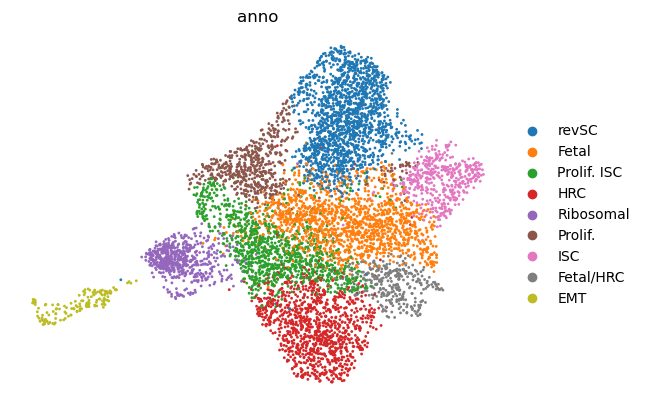

In [20]:
# Annotation UMAP
sc.pl.umap(adata, color=['anno'], frameon=False, title=None)

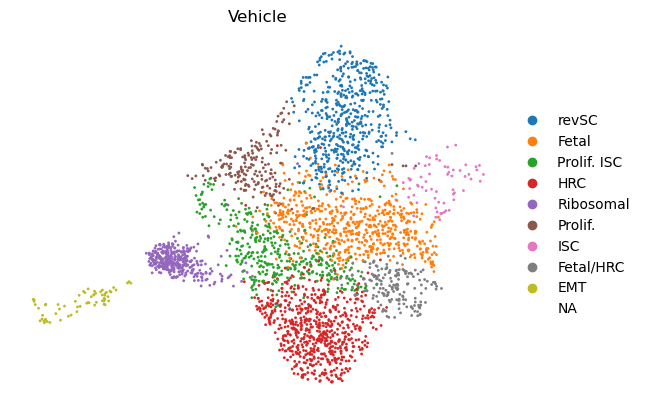

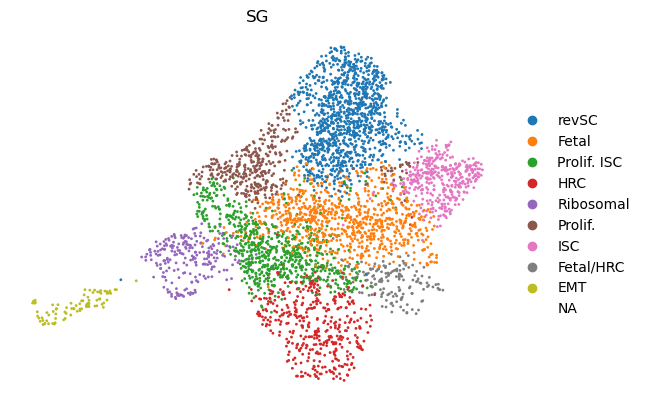

In [21]:
###  UMAP split by treatment condition

# Observation masks
mask_vehicle = adata.obs['treatment'] == 'vehicle'
mask_SG = adata.obs['treatment'] == 'trodelvy'

# Plot UMAPs
sc.pl.umap(adata.copy(), color=['anno'], frameon=False, title='Vehicle', 
           mask_obs=mask_vehicle, na_color='white')

sc.pl.umap(adata.copy(), color=['anno'], frameon=False, title='SG', 
           mask_obs=mask_SG, na_color='white')

## Gene expression UMAP

UMAPs of gene expression patterns:


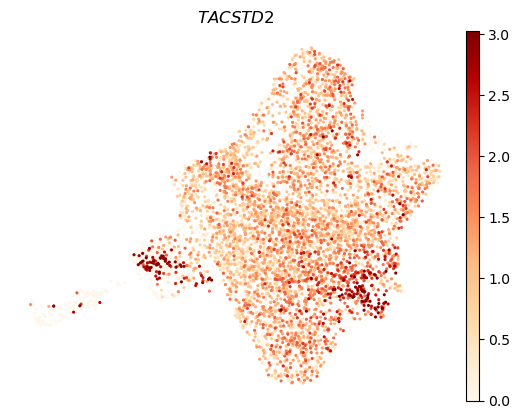

<Figure size 640x480 with 0 Axes>

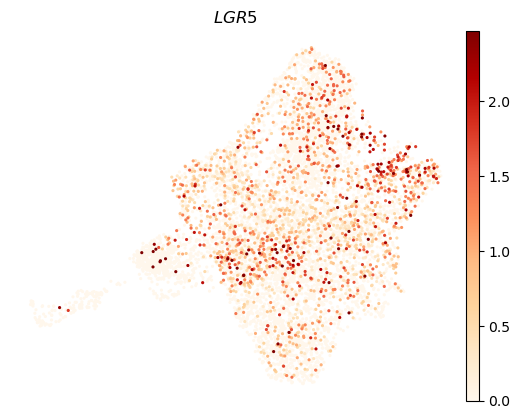

<Figure size 640x480 with 0 Axes>

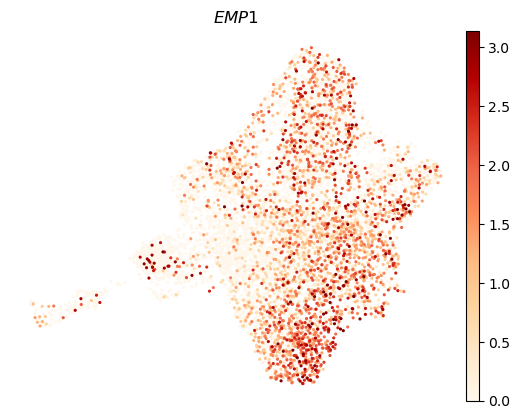

<Figure size 640x480 with 0 Axes>

In [15]:
# Features to plot
features = ['TACSTD2', 'LGR5', 'EMP1']

# Define plotting parameters
vmax = 'p99.5'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot and save UMAPs
    sc.pl.umap(
        adata, 
        color=feature, 
        size=dot_size, 
        cmap='OrRd', 
        vmax=vmax, 
        title=f"$\\it{{{feature}}}$",
        frameon=False
    )
    plt.tight_layout()
    plt.show()

## Treatment response

In [19]:
import pandas as pd
import numpy as np

cell_groups = 'anno'

# Relevant data
df = adata.obs[['sample_id', 'treatment', cell_groups]].copy()

# Count cells per sample–treatment–cluster
counts = (
    df.groupby(['sample_id', 'treatment', cell_groups])
      .size()
      .reset_index(name='count')
)

# Convert to frequencies within each sample+treatment
counts['freq'] = (
    counts.groupby(['sample_id', 'treatment'])['count']
          .transform(lambda x: x / x.sum())
)

# Pivot so each sample has freq per treatment; keep NaN where data is truly missing
freq_pivot = counts.pivot_table(
    index=['sample_id', cell_groups],
    columns='treatment',
    values='freq',
    aggfunc='mean',
    dropna=False  # keeps NaNs instead of filling with 0
)

# Replace structural zeros (= treatment not present for that sample) with NaN
# True zeros (cluster frequency = 0 within a sample) remain 0
freq_pivot = freq_pivot.replace(0, np.nan) # can do as no zero beyond structural zeros

# Compute cluster-wise mean and std across samples, per treatment
summary = (
    freq_pivot
    .groupby(cell_groups)
    .agg(['mean', 'std', 'count'])       # mean freq, SD, number of samples contributing
)

# Extract means per treatment
mean_trodelvy = summary['trodelvy']['mean']
mean_vehicle  = summary['vehicle']['mean']

# Compute log2 fold change based on MEANS
pseudocount = 0 # not needed
log2fc = np.log2((mean_trodelvy + pseudocount) / (mean_vehicle + pseudocount))
fc = (mean_trodelvy + pseudocount) / (mean_vehicle + pseudocount)

# Extract difference in percent
diff_percent = (mean_trodelvy - mean_vehicle)


# Final output
result = pd.DataFrame({
    'mean_vehicle': mean_vehicle,
    'mean_trodelvy': mean_trodelvy,
    'std_vehicle': summary['vehicle']['std'],
    'std_trodelvy': summary['trodelvy']['std'],
    # 'n_vehicle': summary['vehicle']['count'],
    # 'n_trodelvy': summary['trodelvy']['count'],
    'log2FC_trodelvy_vs_vehicle': log2fc,
    'FC_trodelvy_vs_vehicle': fc,
    'diff_trodelvy_vs_vehicle': diff_percent,
})
result.to_csv(f"../data_suppl/{accession}_Fig_03k.csv")
result.sort_values('log2FC_trodelvy_vs_vehicle', ascending=False).head(10)


/tmp/ipykernel_1518359/1974658962.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sample_id', 'treatment', cell_groups])
/tmp/ipykernel_1518359/1974658962.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts.groupby(['sample_id', 'treatment'])['count']
/tmp/ipykernel_1518359/1974658962.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq_pivot = counts.pivot_table(
/tmp/ipykernel_1518359/1974658962.py:38: FutureWarning

,mean_vehicle,mean_trodelvy,std_vehicle,std_trodelvy,log2FC_trodelvy_vs_vehicle,FC_trodelvy_vs_vehicle,diff_trodelvy_vs_vehicle
anno,,,,,,,
ISC,0.020563,0.091280,0.012841,0.013422,2.150269,4.439107,0.070717
revSC,0.174708,0.245467,0.054563,0.072940,0.490588,1.405018,0.070760
Prolif.,0.066812,0.090314,0.014301,0.031640,0.434838,1.351759,0.023502
Prolif. ISC,0.128030,0.171745,0.023543,0.045782,0.423788,1.341445,0.043715
EMT,0.018786,0.019383,0.016487,0.006128,0.045110,1.031761,0.000597
Fetal,0.206749,0.192906,0.034593,0.060730,-0.099980,0.933046,-0.013843
Fetal/HRC,0.057938,0.036397,0.017552,0.005307,-0.670683,0.628209,-0.021541
Ribosomal,0.110877,0.052686,0.042133,0.010842,-1.073472,0.475174,-0.058191
HRC,0.215537,0.099821,0.034979,0.027244,-1.110519,0.463127,-0.115716


In [20]:
# assemble dict which assigns 'up' if fold change > cutoff, 'down' if < 1/cutoff, else 'stable'
def get_treat_resp(x, cutoff):
    if x > (1 + cutoff):
        return 'up'
    elif x < (1 - cutoff):
        return 'down'
    else:
        return 'stable'
    
cutoff = 0.3
treat_resp_dict = {x: get_treat_resp(result.loc[x]['FC_trodelvy_vs_vehicle'], cutoff) for x in result.index}
treat_resp_dict

{'revSC': 'up',
 'Fetal': 'stable',
 'Prolif. ISC': 'up',
 'HRC': 'down',
 'Ribosomal': 'down',
 'Prolif.': 'up',
 'ISC': 'up',
 'Fetal/HRC': 'down',
 'EMT': 'stable'}

In [21]:
# Assign treatment response to adata.obs
adata.obs['treatment_resp'] = adata.obs['anno'].map(treat_resp_dict)

{'treatment_resp': {'order': ['down', 'up', 'stable'], 'colors': ['#5B84B1FF', '#FC766AFF', 'grey']}}


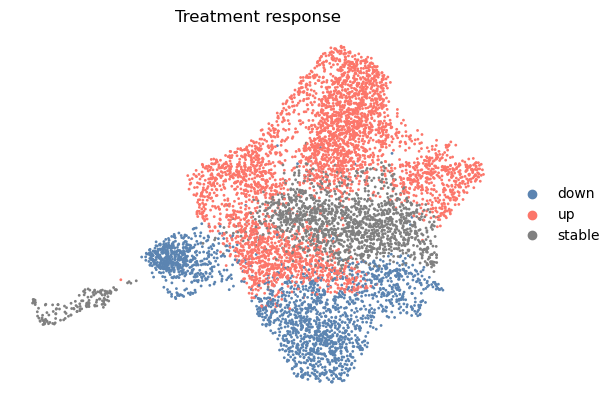

In [22]:
# Set color code and plot UMAP
from utils_treatment_HD4246_SG import color_code
print(color_code)

adata = set_color_code(adata, color_code, feature='treatment_resp')
sc.pl.umap(adata, color=['treatment_resp'], frameon=False, title="Treatment response")

/tmp/ipykernel_1518359/3213015425.py:25: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.violinplot(
/tmp/ipykernel_1518359/3213015425.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([feature_labels[f] for f in df['feature'].unique()])


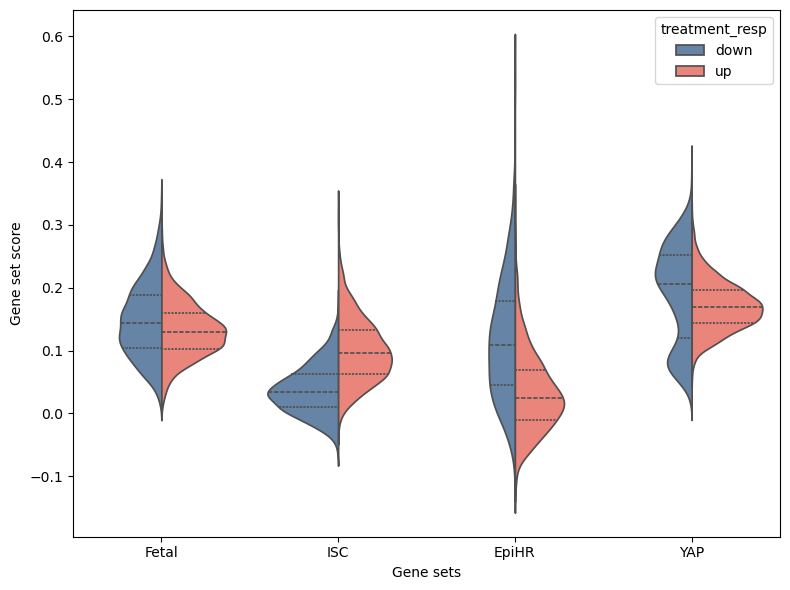

In [23]:
### Gene set expression across treatment response
features = ['score_fetal', 'score_Lgr5', 'score_epiHR', 'score_YAP']
feature_labels = {
    'score_fetal': 'Fetal',
    'score_Lgr5': 'ISC',
    'score_epiHR': 'EpiHR',
    'score_YAP': 'YAP'
}
split_by = 'treatment_resp'

# Extract data into DataFrame
df = adata.obs[[split_by]].copy()  # Copy the metadata into a DataFrame
for feature in features:        
    df[feature] = adata.obs_vector(feature, layer='normalized')
# To long format
df = df.melt(
    id_vars=[split_by], 
    value_vars=features, 
    var_name='feature', 
    value_name='value'
)

# Plot as violin plot
plt.figure(figsize=(8, 6))
ax = sns.violinplot(
    data=df, 
    x='feature', 
    y='value', 
    hue=split_by, 
    hue_order=['down', 'up'],
    split=True, 
    palette=color_code[split_by]['colors'],
    fill=True, 
    inner='quart'
)
plt.xlabel('Gene sets')
plt.ylabel('Gene set score')
# Replace x-tick labels
ax.set_xticklabels([feature_labels[f] for f in df['feature'].unique()])
plt.tight_layout()
plt.show()

In [24]:
df.to_csv(f"../data_suppl/{accession}_Fig_03l.csv", index=False)
df.head()

,treatment_resp,feature,value
0,up,score_fetal,0.146605
1,up,score_fetal,0.207185
2,stable,score_fetal,0.162056
3,up,score_fetal,0.191339
4,up,score_fetal,0.126882


In [25]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

rank_sum = []

# Test differential gene set score across treatment response
for score in gs_process:
    x = df[(df['feature'] == score) & (df['treatment_resp'] == 'up')]['value']
    y = df[(df['feature'] == score) & (df['treatment_resp'] == 'down')]['value']
    # Perform rank sum test
    rank_stat, rank_p_value = mannwhitneyu(x, y, alternative='two-sided', )
    
    # Append results to rank_sum
    rank_sum.append({
        "gene_set": score,
        "median_cl_dn": y.median(),
        "median_cl_up": x.median(),
        "mean_cl_dn": y.mean(),
        "mean_cl_up": x.mean(),
        "rank_statistic": rank_stat,
        "rank_p_value": rank_p_value,
    })

# Convert to DataFrame
rank_sum_df = pd.DataFrame(rank_sum)

# Apply multiple testing correction to the p-values
p_values = rank_sum_df["rank_p_value"].values
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')  # FDR correction (Benjamini-Hochberg)
# Add corrected p-values to the DataFrame
rank_sum_df["rank_p_value_FDR(BH)"] = corrected_p_values
rank_sum_df.to_csv(f"../data_suppl/{accession}_Fig_03l_test.csv", index=False)
rank_sum_df

,gene_set,median_cl_dn,median_cl_up,mean_cl_dn,mean_cl_up,rank_statistic,rank_p_value,rank_p_value_FDR(BH)
0,score_fetal,0.144284,0.130372,0.147672,0.132613,3187373.0,3.786977e-19,3.786977e-19
1,score_Lgr5,0.034425,0.095766,0.037833,0.100280,6236961.0,0.000000e+00,0.000000e+00
2,score_epiHR,0.108594,0.025337,0.116753,0.033257,1732366.0,7.701124e-244,1.540225e-243
3,score_YAP,0.205672,0.168828,0.190511,0.171265,2899272.0,3.582501e-43,4.776669e-43


# Get data from arrayExpress: SG treatment time course liver mets

Data format on arrayExpress needs double-checking for full dataset...

In [4]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata, list_accession_files

accession = "E-MTAB-16849"
download_dir = '../data_arrayExpress'

df_files = list_accession_files(
    accession=accession,
)
print(df_files)

adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    blacklist=[f for f in df_files['path'] if f.startswith('HD4246_SG_mets')],
    dataset = '0h-48h',
)
adata

                                        path        size  type   md5
0                HD4246_SG_0h-48h_counts.txt  1261067986  file  None
1     HD4246_SG_0h-48h_counts_log1p_woCC.txt  3810408828  file  None
2              HD4246_SG_0h-48h_features.txt      221441  file  None
3              HD4246_SG_0h-48h_metadata.txt      783941  file  None
4                  HD4246_SG_0h-48h_umap.txt      478836  file  None
5              HD4246_SG_48h-120h_counts.txt  1549173732  file  None
6   HD4246_SG_48h-120h_counts_log1p_woCC.txt  4717617770  file  None
7            HD4246_SG_48h-120h_features.txt      221441  file  None
8            HD4246_SG_48h-120h_metadata.txt      993348  file  None
9                HD4246_SG_48h-120h_umap.txt      593587  file  None
10                 HD4246_SG_mets_counts.txt  3202358648  file  None
11               HD4246_SG_mets_features.txt      221441  file  None
12               HD4246_SG_mets_metadata.txt     3063293  file  None
13                     feature_ref

AnnData object with n_obs × n_vars = 11385 × 27594
    obs: 'sample_id', 'line', 'treatment', 'timepoint', 'replicate', 'library', 'leiden', 'batch'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

## UMAP with gene expression

requires import of MAGIG imputed counts

In [60]:
# # Features to plot
# features = ['TACSTD2']

# # Define plotting parameters
# vmax = 'p99.5'
# dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# # Make UMAPs of gene set scores
# print("UMAPs of gene expression patterns:")
# for feature in features:    
#     # Plot and save UMAPs
#     sc.pl.umap(
#         adata, 
#         layer = 'magic',
#         color=feature, 
#         size=dot_size, 
#         cmap='OrRd', 
#         vmax=vmax, 
#         title=f"$\\it{{{feature}}}$",
#         frameon=False
#     )
#     plt.tight_layout()
#     plt.show()

In [24]:
# Import gene sets
import utils
print("Writing gene set details into anndata object...")
adata = utils.get_gene_sets(adata, verbose=False)

Writing gene set details into anndata object...


In [25]:
# Compute gene set scores
import utils_genelist as genelist
features = ['score_Lgr5', 'score_fetal']
for feature in features:
    genes = adata.uns['gene_sets'][adata.uns['gene_sets']['gene_set'] == feature]['gene']
    adata = genelist.compute_gene_score(
        adata, 
        genes, 
        score_name=feature, 
        layer='log1p', 
        verbose=False
    )

double-check color scale

UMAPs of gene set scores:


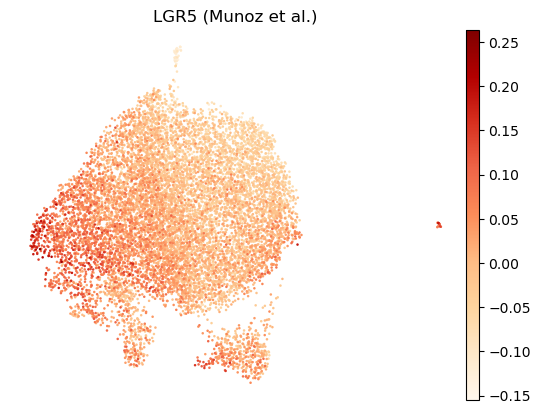

In [ ]:
# Settings for UMAPs of gene set scores
vmax = 'p99.5'
dot_size = 120000 / adata.shape[0] * 1.25

# Plotting labels for gene set scores
feature_labels = {
    'score_Lgr5': 'LGR5 (Munoz et al.)',
}

# Make UMAPs of gene set scores
print("UMAPs of gene set scores:") 
sc.pl.umap(
    adata, 
    color=feature_labels.keys(), 
    size=dot_size,
    title=feature_labels.values(),
    cmap='OrRd', 
    # vmax=vmax, 
    frameon=False
)

## UMAP with timepoint

{'treatment': {'order': ['ADC', 'SG'], 'colors': {'ADC': '#9d9da1', 'SG': '#ad7bb6'}}, 'timepoint': {'order': ['0h', '6h', '24h', '48h', '72h', '120h'], 'colors': {'0h': '#fee187', '6h': '#fd9841', '24h': '#cf0c21', '48h': '#8e44ad', '72h': '#135fa7', '120h': '#72b2d8'}}, 'treatment_response_48h': {'order': ['0h', 'same', '48h'], 'colors': {'0h': '#fee187', 'same': '#808080', '48h': '#8e44ad'}}, 'treatment_response_120h': {'order': ['48h', 'same', '120h'], 'colors': {'48h': '#8e44ad', 'same': '#808080', '120h': '#fee187'}}}


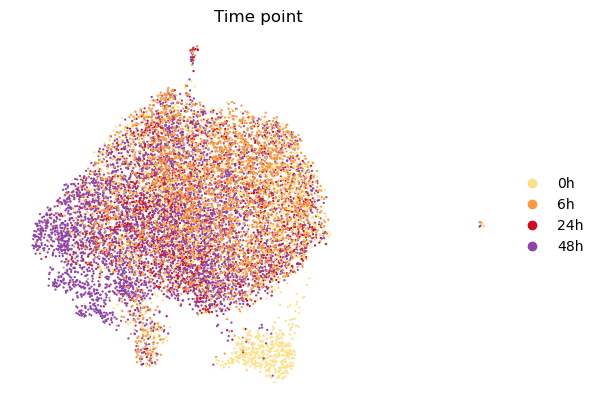

In [5]:
# Set color code and plot UMAP
from utils_SG_timecourse import color_code
import utils
print(color_code)

# adata = set_color_code(adata, color_code, feature='timepoint')
utils.set_uns_colors(adata, color_code, key='timepoint')
sc.pl.umap(adata, color=['timepoint'], frameon=False, title="Time point")

## Treatment response

In [6]:
# Difference in cluster size between 48h and 0h
def get_composition(adata, x, y, cond=None,  abs_count=True):

    # Use index as cell barcode column
    cell_bc="cell_bc"
    adata.obs[cell_bc] = adata.obs.index

    # Compute absolute frequency table
    freq = adata.obs.pivot_table(index=x, columns=cond, values=[cell_bc], aggfunc={cell_bc: 'count'})
    # Rename columns
    cell_count_label = 'no_cells'
    colnames = {cell_bc: cell_count_label,}
    freq.rename(columns=colnames, inplace=True)
    
    # Adapt column labels and normalize data if applicable
    if not abs_count:
        # Normalize data and write to new object
        freq_rel = freq.div(freq.sum(axis=1), axis=0)*100
        # Rename columns
        cell_count_label = 'rel_no_cells'
        colnames = {'no_cells': cell_count_label,}
        freq_rel.rename(columns=colnames, inplace=True)
    
    if abs_count:
        return freq
    else:
        return freq_rel

# Get relative composition of clusters across samples
df = get_composition(adata, x='sample_id', y='count', cond='leiden', abs_count=False)

# Convert to long format
df = df.stack().reset_index()
df['treatment'] = [x.split('_')[1] for x in df['sample_id']]
df['timepoint'] = [x.split('_')[2] for x in df['sample_id']]
df['sample_name'] = [x.rsplit('_',1)[0] for x in df['sample_id']]
print(df.head(2))

            sample_id  leiden  rel_no_cells treatment timepoint   sample_name
0  HD4246_SG_0h_repl1       0     14.929817        SG        0h  HD4246_SG_0h
1  HD4246_SG_0h_repl1       1     19.225861        SG        0h  HD4246_SG_0h


/tmp/ipykernel_3519079/2212485140.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq = adata.obs.pivot_table(index=x, columns=cond, values=[cell_bc], aggfunc={cell_bc: 'count'})
/tmp/ipykernel_3519079/2212485140.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack().reset_index()


In [7]:
### Plot cluster difference between 48h and 0h

# Summarize relative composition by treatment and cluster
df_sum = df.groupby(['timepoint', 'leiden'])['rel_no_cells'].mean().reset_index()

# Get df subset with only 48h and 0h timepoints
df_sub = df_sum[df_sum['timepoint'].isin(['48h', '0h'])]

# Get difference between treatment options: '48h' - '0h'
pivot_df = df_sub.pivot(index='leiden', columns='timepoint', values='rel_no_cells')
pivot_df['diff'] = pivot_df['48h'] - pivot_df['0h']
pivot_df['log2FC'] = np.log2((pivot_df['48h'] + 1e-6) / (pivot_df['0h'] + 1e-6)) # add pseudocount to avoid log2(0)

pivot_df

timepoint,0h,48h,diff,log2FC
leiden,,,,
0,14.929817,33.316253,18.386436,1.158030
1,19.225861,16.001223,-3.224638,-0.264866
2,27.903020,9.507540,-18.395480,-1.553277
3,15.312633,15.996999,0.684366,0.063079
4,3.062527,17.224919,14.162392,2.491703
5,1.276053,7.005036,5.728983,2.456703
6,17.864738,0.617103,-17.247636,-4.855458
7,0.170140,0.198753,0.028613,0.224251
8,0.255211,0.132175,-0.123035,-0.949231


In [8]:
# Derive cluster response based on log2FC in composition
def get_treat_resp(x, log2_cutoff,
                   label_up='up',
                   label_down='down',
                   label_stable='stable'):
    if x > log2_cutoff:
        return label_up
    elif x < -log2_cutoff:
        return label_down
    else:
        return label_stable
    
cutoff = np.log2(2)
treat_resp_dict = {x: get_treat_resp(pivot_df.loc[x]['log2FC'], cutoff, label_up='48h', label_down='0h', label_stable='same') for x in pivot_df.index}
treat_resp_dict

{0: '48h',
 1: 'same',
 2: '0h',
 3: 'same',
 4: '48h',
 5: '48h',
 6: '0h',
 7: 'same',
 8: 'same'}

In [10]:
# Assign treatment response to adata.obs
treatment_key = 'treatment_response_48h'
adata.obs[treatment_key] = adata.obs['leiden'].map(treat_resp_dict)

# Assign color codea
utils.set_uns_colors(adata, color_code, treatment_key)

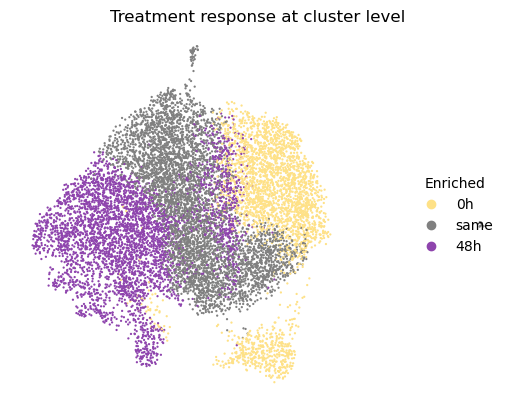

In [11]:
# Make UMAP of treatment response
ax = sc.pl.umap(adata, color=treatment_key, frameon=False, title="Treatment response at cluster level", show=False)
ax.legend(title='Enriched', loc='right', frameon=False)

## Gene set distribution by treatment response

check gene expression in violin plot below

  treatment_response_48h     feature     value
0                   same  score_Lgr5 -0.023310
1                   same  score_Lgr5 -0.019149


/tmp/ipykernel_3519079/1455614741.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([feature_labels[f] for f in df['feature'].unique()])


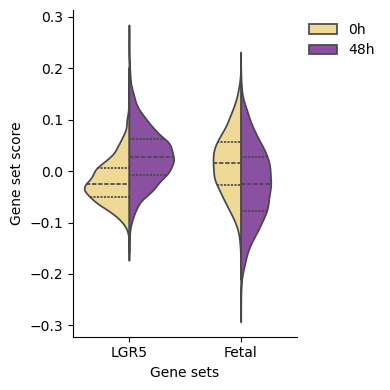

In [ ]:
### Gene set expression across treatment response
features = ['score_Lgr5', 'score_fetal']
feature_labels = {
    'score_Lgr5': 'LGR5',
    'score_fetal': 'Fetal',
}
split_by = treatment_key

# Extract data into DataFrame
df = adata.obs[[split_by]].copy()  # Copy the metadata into a DataFrame
for feature in features:        
    df[feature] = adata.obs_vector(feature, layer='log1p')
# To long format
df = df.melt(
    id_vars=[split_by], 
    value_vars=features, 
    var_name='feature', 
    value_name='value'
)

# Plot as violin plot
plt.figure(figsize=(4, 4))
ax = sns.violinplot(
    data=df, 
    x='feature', 
    y='value', 
    hue=split_by, 
    hue_order=['0h', '48h'],
    split=True, 
    palette=color_code[split_by]['colors'],
    fill=True, 
    inner='quart'
)
plt.xlabel('Gene sets')
plt.ylabel('Gene set score')
# Replace x-tick labels
ax.set_xticklabels([feature_labels[f] for f in df['feature'].unique()])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(title='', loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.tight_layout()
plt.show()

In [20]:
df.to_csv(f"../data_suppl/{accession}_Fig_03q.csv", index=False)
df.head()

,treatment_response_48h,feature,value
0,same,score_Lgr5,-0.023310
1,same,score_Lgr5,-0.019149
2,0h,score_Lgr5,0.000689
3,48h,score_Lgr5,-0.035828
4,same,score_Lgr5,0.042925


In [23]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

rank_sum = []

# Test differential gene set score across treatment response
for score in features:
    x = df[(df['feature'] == score) & (df[treatment_key] == '48h')]['value']
    y = df[(df['feature'] == score) & (df[treatment_key] == '0h')]['value']
    # Perform rank sum test
    rank_stat, rank_p_value = mannwhitneyu(x, y, alternative='two-sided', )
    
    # Append results to rank_sum
    rank_sum.append({
        "gene_set": score,
        "median_cl_dn": y.median(),
        "median_cl_up": x.median(),
        "mean_cl_dn": y.mean(),
        "mean_cl_up": x.mean(),
        "rank_statistic": rank_stat,
        "rank_p_value": rank_p_value,
    })

# Convert to DataFrame
rank_sum_df = pd.DataFrame(rank_sum)

# Apply multiple testing correction to the p-values
p_values = rank_sum_df["rank_p_value"].values
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')  # FDR correction (Benjamini-Hochberg)
# Add corrected p-values to the DataFrame
rank_sum_df["rank_p_value_FDR(BH)"] = corrected_p_values
rank_sum_df.to_csv(f"../data_suppl/{accession}_Fig_03q_test.csv", index=False)
rank_sum_df

,gene_set,median_cl_dn,median_cl_up,mean_cl_dn,mean_cl_up,rank_statistic,rank_p_value,rank_p_value_FDR(BH)
0,score_Lgr5,-0.024826,0.026501,-0.020464,0.028118,8301737.0,5.145274e-295,1.029055e-294
1,score_fetal,0.014963,-0.024255,0.015297,-0.024364,3740728.0,2.480057e-105,2.480057e-105
